# Deep Q-Learning with Taxi

In this notebook we solve the Gymnasium Taxi environment using a **Deep Q-Network**, usually shortened to **DQN**.

The tabular Q-learning solution is still the simplest choice for Taxi because Taxi has only 500 discrete states. DQN is useful here as the deep-learning version of the same idea: instead of storing one Q-value per `(state, action)` in a table, we train a neural network to predict Q-values.

The job is still the same:

1. Drive to the passenger.
2. Pick them up.
3. Drive to the destination.
4. Drop them off.

The DQN pieces we will build are:

- one-hot state vectors
- a small PyTorch neural network
- epsilon-greedy exploration
- replay memory
- a policy network and a target network
- the Bellman target update


## Step -1: Install dependencies

If you are running this on Google Colab or a fresh environment, run the cell below. If the packages are already installed locally, this should be quick.


In [1]:
%pip install -q "gymnasium[toy-text]" torch matplotlib


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchvision 0.25.0 requires torch==2.10.0, but you have torch 2.12.0 which is incompatible.
tensorflow 2.16.2 requires numpy<2.0.0,>=1.23.5; python_version <= "3.11", but you have numpy 2.4.6 which is incompatible.
tensorflow 2.16.2 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 6.33.6 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


## Step 0: Import libraries

We use:

- `gymnasium` for the Taxi environment
- `torch` for the neural network
- `numpy` for averages and plotting helpers
- `random` for epsilon-greedy exploration
- `deque` for replay memory


In [2]:
import math
import random
from collections import deque, namedtuple
from dataclasses import dataclass

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


## Step 1: Configuration

These values control the learning process. Keeping them in one class makes the experiment easier to tune.

A few important ones:

- `gamma`: how much future reward matters
- `learning_rate`: how fast the neural network changes
- `batch_size`: how many old experiences we train from at once
- `target_update_steps`: how often we copy the policy network into the target network
- `max_epsilon`, `min_epsilon`, `decay_rate`: how exploration decreases over time


In [3]:
# One saved experience from the agent.
# Example: "I was in state s, took action a, received reward r,
# moved to next_state, and the episode either did or did not finish."
Transition = namedtuple("Transition", ("state", "action", "reward", "next_state", "done"))


@dataclass
class DQNConfig:
    seed: int = 7
    episodes: int = 500
    max_steps_per_episode: int = 200

    # Discount factor for future reward.
    # gamma = 0 means only immediate reward matters.
    # gamma close to 1 means future reward matters a lot.
    gamma: float = 0.99

    # Neural-network optimizer settings.
    learning_rate: float = 1e-3
    batch_size: int = 64

    # Replay memory settings.
    replay_capacity: int = 50_000
    min_replay_size: int = 500

    # Train once per environment step after the replay buffer has enough data.
    train_frequency: int = 1

    # Copy policy_net weights into target_net every N environment steps.
    target_update_steps: int = 250

    # Exploration schedule.
    max_epsilon: float = 1.0
    min_epsilon: float = 0.05
    decay_rate: float = 0.0015

    # Greedy evaluation after training.
    eval_episodes: int = 100


config = DQNConfig()
config


DQNConfig(seed=7, episodes=500, max_steps_per_episode=200, gamma=0.99, learning_rate=0.001, batch_size=64, replay_capacity=50000, min_replay_size=500, train_frequency=1, target_update_steps=250, max_epsilon=1.0, min_epsilon=0.05, decay_rate=0.0015, eval_episodes=100)

## Step 2: Create the Taxi environment

Taxi has:

- 500 states
- 6 actions

The state is still an integer, but that integer encodes:

```text
taxi row, taxi column, passenger location, destination
```

The actions are:

```text
0 = south
1 = north
2 = east
3 = west
4 = pickup
5 = dropoff
```


In [4]:
def make_taxi_env(render_mode=None):
    """Create Taxi in a way that works across Gymnasium versions."""

    # Newer Gymnasium versions use Taxi-v4; older ones use Taxi-v3.
    for env_name in ("Taxi-v4", "Taxi-v3"):
        try:
            return gym.make(env_name, render_mode=render_mode)
        except Exception:
            pass
    raise RuntimeError("Could not create Taxi-v4 or Taxi-v3. Try installing gymnasium[toy-text].")


def set_seed(seed, env):
    """Seed Python, NumPy, PyTorch, and the environment action space."""

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    env.action_space.seed(seed)


env = make_taxi_env()
set_seed(config.seed, env)

n_states = env.observation_space.n
n_actions = env.action_space.n

# Taxi is small, so CPU is perfectly fine and often fastest for this assignment.
device = torch.device("cpu")

print("Number of states:", n_states)
print("Number of actions:", n_actions)
print("Device:", device)


Number of states: 500
Number of actions: 6
Device: cpu


## Step 3: Convert state IDs into one-hot vectors

A neural network should not receive the raw Taxi state integer directly.

Why? Because state `499` is not mathematically "larger" than state `12`. These numbers are just IDs. A one-hot vector treats each state as its own separate category.

For Taxi, every state becomes a vector of length 500:

```text
state 0   -> [1, 0, 0, ..., 0]
state 1   -> [0, 1, 0, ..., 0]
state 499 -> [0, 0, 0, ..., 1]
```


In [5]:
def states_to_one_hot(states, n_states):
    """Convert integer state IDs into one-hot vectors."""

    return F.one_hot(states.long(), num_classes=n_states).float()


example_states = torch.tensor([0, 1, 499])
example_vectors = states_to_one_hot(example_states, n_states)

print("Example one-hot tensor shape:", example_vectors.shape)
print("First vector has a 1 at index:", int(example_vectors[0].argmax()))
print("Last vector has a 1 at index:", int(example_vectors[-1].argmax()))


Example one-hot tensor shape: torch.Size([3, 500])
First vector has a 1 at index: 0
Last vector has a 1 at index: 499


## Step 4: Build the Q-network

The network estimates this function:

```text
Q(state, action)
```

But instead of giving it both a state and an action, we give it the state and ask it to output one Q-value for every possible action.

So the shape is:

```text
input:  500 numbers, the one-hot state
output: 6 numbers, one Q-value per action
```

Then the best action is just the index of the largest output value.


In [6]:
class QNetwork(nn.Module):
    """Small neural network that predicts Q-values for all Taxi actions."""

    def __init__(self, n_states, n_actions):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(n_states, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, n_actions),
        )

    def forward(self, x):
        return self.layers(x)


# A quick architecture preview.
demo_net = QNetwork(n_states, n_actions).to(device)
demo_input = states_to_one_hot(torch.tensor([0]), n_states).to(device)
demo_output = demo_net(demo_input)

print(demo_net)
print("Output shape for one state:", demo_output.shape)
print("One predicted Q-value per action:", demo_output.detach().numpy().round(3))


QNetwork(
  (layers): Sequential(
    (0): Linear(in_features=500, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=6, bias=True)
  )
)
Output shape for one state: torch.Size([1, 6])
One predicted Q-value per action: [[ 0.067 -0.057 -0.004  0.031 -0.047 -0.024]]


## Why DQN uses two networks

DQN normally uses two neural networks:

```text
policy_net: the network we train every optimizer step
target_net: a slower copy used to calculate Bellman targets
```

The policy network predicts the current Q-value:

```text
Q_policy(state, action)
```

The target network estimates the future part:

```text
reward + gamma * max_a Q_target(next_state, a)
```

If the same network predicted both sides, the network would be chasing a target that moves every time it learns. The target network changes more slowly, so the learning target is steadier.

Every few hundred environment steps we copy:

```python
target_net.load_state_dict(policy_net.state_dict())
```


## Step 5: Replay memory

In normal gameplay, consecutive states are highly related. For example, if the taxi moves east, the next state is probably almost the same as the previous one.

Neural networks train better when batches are mixed. Replay memory stores old experiences and lets us sample random batches from them.


In [7]:
class ReplayMemory:
    """Fixed-size memory of past transitions."""

    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, transition):
        self.memory.append(transition)

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)


## Step 6: Epsilon-greedy action selection

At each step, the agent chooses between exploration and exploitation.

```text
with probability epsilon: choose a random action
otherwise: choose the action with the highest predicted Q-value
```

We decay epsilon over episodes using:

```python
epsilon = min_epsilon + (max_epsilon - min_epsilon) * exp(-decay_rate * episode)
```

So training starts very exploratory and becomes more greedy later.


In [8]:
def epsilon_for_episode(episode, config):
    """Exponential decay from max_epsilon down toward min_epsilon."""

    return config.min_epsilon + (config.max_epsilon - config.min_epsilon) * math.exp(
        -config.decay_rate * episode
    )


def select_action(state, epsilon, env, policy_net, n_states, device):
    """Choose an action using epsilon-greedy exploration."""

    # Explore: try a random valid action.
    if random.random() < epsilon:
        return int(env.action_space.sample())

    # Exploit: use the network and choose the action with the largest Q-value.
    # We do not need gradients here because selecting an action is not training.
    with torch.no_grad():
        state_tensor = torch.tensor([state], device=device)
        state_one_hot = states_to_one_hot(state_tensor, n_states)
        q_values = policy_net(state_one_hot)
        return int(q_values.argmax(dim=1).item())


for episode in [1, 100, 500, 1000]:
    print(f"episode {episode:4d} -> epsilon {epsilon_for_episode(episode, config):.3f}")


episode    1 -> epsilon 0.999
episode  100 -> epsilon 0.868
episode  500 -> epsilon 0.499
episode 1000 -> epsilon 0.262


## Step 7: One DQN training update

This is the core learning formula.

The network predicts the Q-value for the action we actually took:

```text
predicted_q = Q_policy(state, action)
```

The target is the reward plus the best future value:

```text
target_q = reward + gamma * max_a Q_target(next_state, a)
```

If the episode is finished, there is no future reward:

```text
target_q = reward
```

Then we train the policy network to make `predicted_q` closer to `target_q`.


In [9]:
def train_step(memory, policy_net, target_net, optimizer, config, n_states, device):
    """Run one optimizer update from a random replay-memory batch."""

    # Wait until we have enough examples to sample useful random batches.
    if len(memory) < config.min_replay_size:
        return None

    transitions = memory.sample(config.batch_size)
    batch = Transition(*zip(*transitions))

    states = torch.tensor(batch.state, device=device)
    actions = torch.tensor(batch.action, device=device)
    rewards = torch.tensor(batch.reward, dtype=torch.float32, device=device)
    next_states = torch.tensor(batch.next_state, device=device)
    dones = torch.tensor(batch.done, dtype=torch.float32, device=device)

    state_vectors = states_to_one_hot(states, n_states)
    next_state_vectors = states_to_one_hot(next_states, n_states)

    # policy_net(state) returns 6 Q-values.
    # gather selects only the Q-value for the action that was actually taken.
    predicted_q = policy_net(state_vectors).gather(1, actions.unsqueeze(1)).squeeze(1)

    with torch.no_grad():
        # The target network gives the future-value estimate.
        # Because it changes slowly, the target is less unstable.
        best_next_q = target_net(next_state_vectors).max(dim=1).values

        # If done is 1, the future term becomes zero.
        target_q = rewards + config.gamma * (1.0 - dones) * best_next_q

    # Smooth L1 loss, also called Huber loss, is common in DQN.
    # It is less sensitive to large errors than plain MSE.
    loss = F.smooth_l1_loss(predicted_q, target_q)

    optimizer.zero_grad()
    loss.backward()

    # Clip gradients to avoid rare huge updates.
    nn.utils.clip_grad_norm_(policy_net.parameters(), max_norm=10.0)

    optimizer.step()
    return float(loss.item())


## Step 8: Train the DQN agent

The loop below does this repeatedly:

1. Reset Taxi at the start of each episode.
2. Pick actions using epsilon-greedy exploration.
3. Store each transition in replay memory.
4. Sample random batches from replay memory.
5. Train the policy network using Bellman targets from the target network.
6. Occasionally copy policy network weights into the target network.

The printed average reward should become less negative as the agent learns. Taxi rewards are harsh early on because random pickup/dropoff actions often receive `-10`.


In [10]:
def train_dqn(config):
    """Train the DQN agent and return the trained network plus logs."""

    env = make_taxi_env()
    set_seed(config.seed, env)

    n_states = env.observation_space.n
    n_actions = env.action_space.n
    device = torch.device("cpu")

    policy_net = QNetwork(n_states, n_actions).to(device)
    target_net = QNetwork(n_states, n_actions).to(device)

    # At the start, both networks have identical weights.
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=config.learning_rate)
    memory = ReplayMemory(config.replay_capacity)

    episode_rewards = []
    losses = []
    global_step = 0

    env.reset(seed=config.seed)

    for episode in range(1, config.episodes + 1):
        state, _ = env.reset()
        epsilon = epsilon_for_episode(episode, config)
        total_reward = 0.0

        for _ in range(config.max_steps_per_episode):
            global_step += 1

            action = select_action(state, epsilon, env, policy_net, n_states, device)
            next_state, reward, terminated, truncated, _ = env.step(action)

            # terminated means the task ended naturally.
            # truncated usually means the 200-step time limit was reached.
            done = terminated or truncated

            memory.push(Transition(state, action, reward, next_state, done))

            loss = None
            if global_step % config.train_frequency == 0:
                loss = train_step(memory, policy_net, target_net, optimizer, config, n_states, device)
            if loss is not None:
                losses.append(loss)

            state = next_state
            total_reward += reward

            # This is the key DQN stabilization trick: update the target network
            # only sometimes, not after every optimizer step.
            if global_step % config.target_update_steps == 0:
                target_net.load_state_dict(policy_net.state_dict())

            if done:
                break

        episode_rewards.append(total_reward)

        if episode % 100 == 0:
            avg_reward = float(np.mean(episode_rewards[-100:]))
            print(
                f"Episode {episode:4d} | "
                f"avg reward last 100: {avg_reward:6.2f} | "
                f"epsilon: {epsilon:5.3f} | "
                f"replay size: {len(memory):5d}"
            )

    env.close()
    return policy_net, episode_rewards, losses


policy_net, episode_rewards, losses = train_dqn(config)


Episode  100 | avg reward last 100: -729.38 | epsilon: 0.868 | replay size: 19547
Episode  200 | avg reward last 100: -449.71 | epsilon: 0.754 | replay size: 33192
Episode  300 | avg reward last 100: -203.09 | epsilon: 0.656 | replay size: 40754
Episode  400 | avg reward last 100: -102.68 | epsilon: 0.571 | replay size: 45193
Episode  500 | avg reward last 100: -54.83 | epsilon: 0.499 | replay size: 48366


## Step 9: Plot training progress

The raw episode reward is noisy, so the moving average is usually easier to read.

A good Taxi policy usually gets around `+8` average reward and finishes in about 13 steps. During training, the reward curve starts very negative because the agent explores many bad actions.


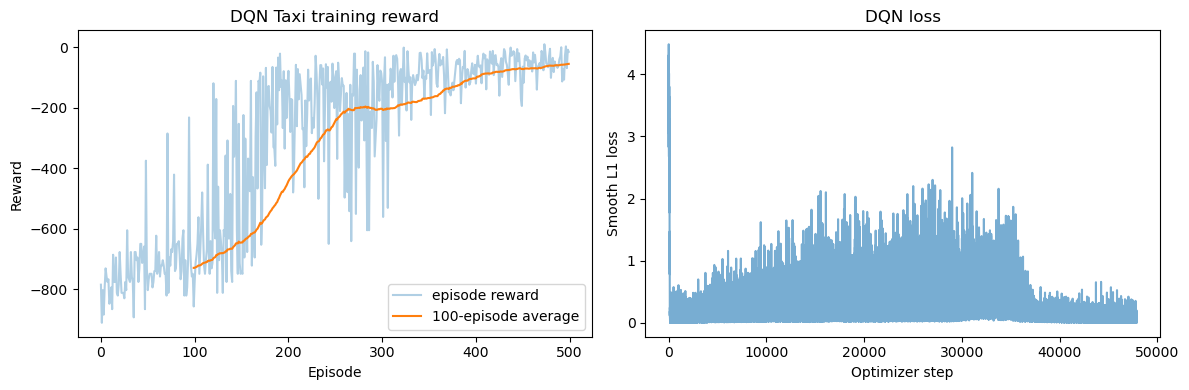

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(episode_rewards, alpha=0.35, label="episode reward")
if len(episode_rewards) >= 100:
    moving_avg = np.convolve(episode_rewards, np.ones(100) / 100, mode="valid")
    axes[0].plot(range(99, len(episode_rewards)), moving_avg, label="100-episode average")
axes[0].set_title("DQN Taxi training reward")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Reward")
axes[0].legend()

axes[1].plot(losses, alpha=0.6)
axes[1].set_title("DQN loss")
axes[1].set_xlabel("Optimizer step")
axes[1].set_ylabel("Smooth L1 loss")

plt.tight_layout()
plt.show()


## Step 10: Evaluate the trained agent

Now we turn exploration off:

```text
epsilon = 0
```

That means the agent always chooses the action with the highest predicted Q-value.

This evaluation tells us whether the learned policy actually solves Taxi, rather than just sometimes succeeding by random exploration.


In [12]:
def evaluate_agent(policy_net, env, episodes, max_steps, seed):
    """Evaluate the agent greedily, with no random exploration."""

    n_states = env.observation_space.n
    device = torch.device("cpu")
    rewards = []
    steps_taken = []
    successes = 0

    for episode in range(episodes):
        state, _ = env.reset(seed=seed + episode)
        total_reward = 0.0

        for step in range(max_steps):
            action = select_action(
                state=state,
                epsilon=0.0,
                env=env,
                policy_net=policy_net,
                n_states=n_states,
                device=device,
            )

            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward

            if terminated:
                successes += 1
                break
            if truncated:
                break

        rewards.append(total_reward)
        steps_taken.append(step + 1)

    return float(np.mean(rewards)), float(np.mean(steps_taken)), successes


eval_env = make_taxi_env()
avg_reward, avg_steps, successes = evaluate_agent(
    policy_net=policy_net,
    env=eval_env,
    episodes=config.eval_episodes,
    max_steps=config.max_steps_per_episode,
    seed=config.seed + 10_000,
)
eval_env.close()

print("Evaluation with epsilon = 0, so the agent is greedy:")
print(f"  average reward : {avg_reward:.2f}")
print(f"  average steps  : {avg_steps:.1f}")
print(f"  success rate   : {successes}/{config.eval_episodes}")


Evaluation with epsilon = 0, so the agent is greedy:
  average reward : 8.04
  average steps  : 13.0
  success rate   : 100/100


## Step 11: Watch one text replay

This final cell shows one greedy run using Taxi's text renderer. It is optional, but useful for checking the learned behavior step by step.


In [13]:
replay_env = make_taxi_env(render_mode="ansi")
state, _ = replay_env.reset(seed=config.seed + 20_000)

total_reward = 0
for step in range(config.max_steps_per_episode):
    action = select_action(
        state=state,
        epsilon=0.0,
        env=replay_env,
        policy_net=policy_net,
        n_states=replay_env.observation_space.n,
        device=torch.device("cpu"),
    )

    state, reward, terminated, truncated, _ = replay_env.step(action)
    total_reward += reward

    print(replay_env.render())
    print(f"step={step + 1}, action={action}, reward={reward}, total={total_reward}")

    if terminated or truncated:
        break

replay_env.close()


+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (North)

step=1, action=1, reward=-1, total=-1
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (North)

step=2, action=1, reward=-1, total=-2
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (East)

step=3, action=2, reward=-1, total=-3
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (East)

step=4, action=2, reward=-1, total=-4
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (North)

step=5, action=1, reward=-1, total=-5
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (East)

step=6, action=2, reward=-1, total=-6
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (North)

step=7, action=1, reward=-1, total=-7
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
